/tmp/ipykernel_2857/3336789411.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='revenue', y='region', data=region_revenue, ax=axes[1, 0], palette='viridis')


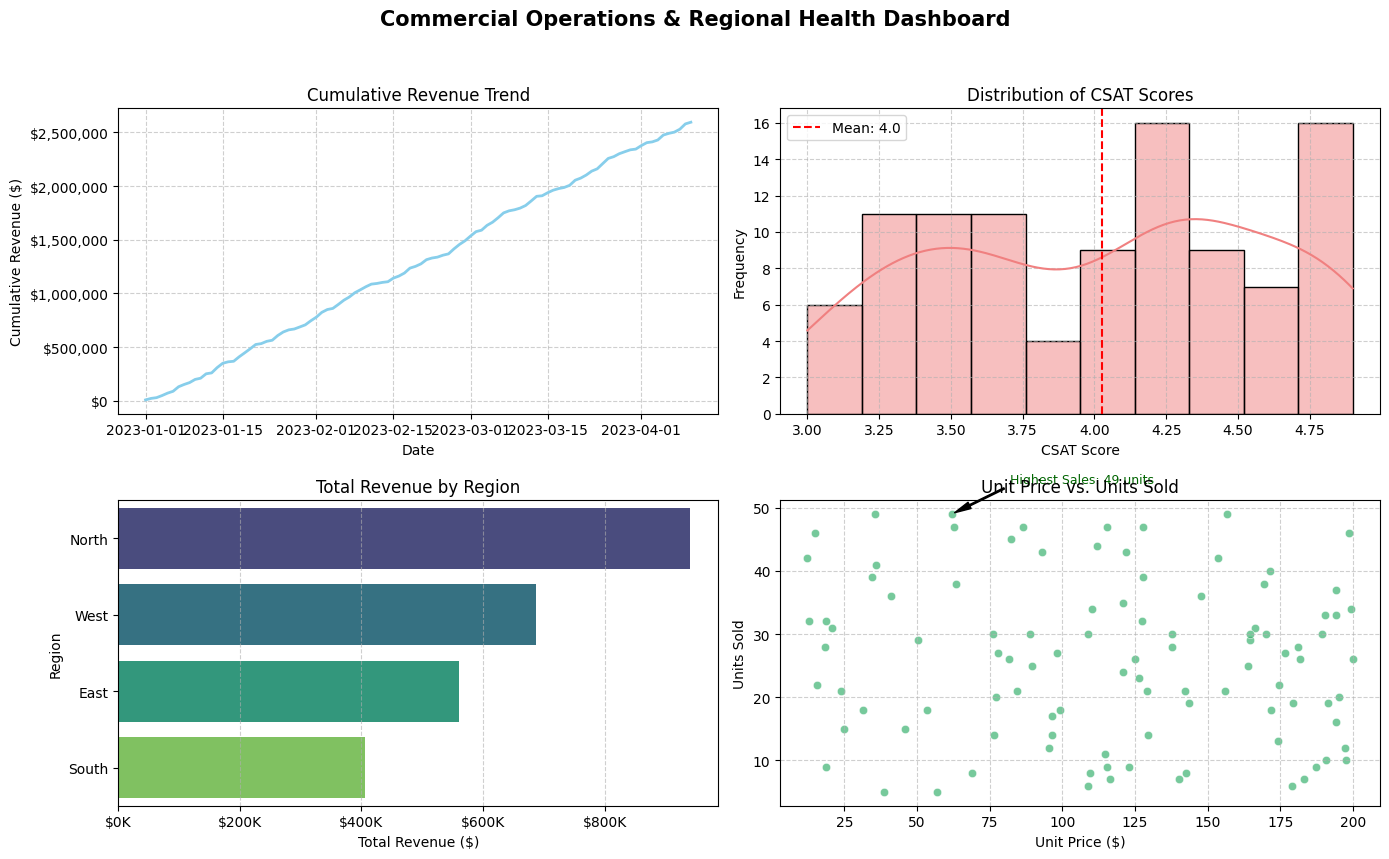

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate sample data for demonstration
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
data = {
    'date': dates,
    'volume': np.random.randint(100, 1000, 100),
    'revenue': np.random.uniform(5000, 50000, 100),
    'csat': np.random.uniform(3.0, 5.0, 100).round(1),
    'margin': np.random.uniform(0.1, 0.4, 100).round(2),
    'region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'tier': np.random.choice(['A', 'B', 'C'], 100),
    'unit_price': np.random.uniform(10, 200, 100).round(2),
    'units_sold': np.random.randint(5, 50, 100),
    'discount': np.random.uniform(0, 0.2, 100).round(2),
    'profit': np.random.uniform(100, 5000, 100)
}
df = pd.DataFrame(data)

# Ensure date is datetime for plotting
df['date'] = pd.to_datetime(df['date'])

# Calculate cumulative revenue for Panel 1
df = df.sort_values(by='date')
df['cumulative_revenue'] = df['revenue'].cumsum()

# 1. Initialize Figure and 2x2 Subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Commercial Operations & Regional Health Dashboard", fontsize=15, fontweight="bold")

# TODO 1: Complete Panel [0, 0] - Trend Analysis (Cumulative Revenue)
axes[0, 0].plot(df['date'], df['cumulative_revenue'], color='skyblue', linewidth=2)
axes[0, 0].set_title('Cumulative Revenue Trend', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Revenue ($)')
axes[0, 0].ticklabel_format(style='plain', axis='y') # Avoid scientific notation
# Format y-axis to show dollar and millions
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# TODO 2: Complete Panel [0, 1] - Distribution Analysis (CSAT Score)
sns.histplot(df['csat'], bins=10, kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Distribution of CSAT Scores', fontsize=12)
axes[0, 1].set_xlabel('CSAT Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['csat'].mean(), color='red', linestyle='--', label=f'Mean: {df["csat"].mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# TODO 3: Complete Panel [1, 0] - Categorical Comparison (Revenue by Region)
region_revenue = df.groupby('region')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False)
sns.barplot(x='revenue', y='region', data=region_revenue, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Total Revenue by Region', fontsize=12)
axes[1, 0].set_xlabel('Total Revenue ($)')
axes[1, 0].set_ylabel('Region')
# Format x-axis to show dollar and thousands/millions
axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.6)

# TODO 4: Complete Panel [1, 1] - Bivariate Relationship (Unit Price vs Units Sold)
sns.scatterplot(x='unit_price', y='units_sold', data=df, ax=axes[1, 1], alpha=0.7, color='mediumseagreen')
axes[1, 1].set_title('Unit Price vs. Units Sold', fontsize=12)
axes[1, 1].set_xlabel('Unit Price ($)')
axes[1, 1].set_ylabel('Units Sold')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
# Add annotation
max_sales_point = df.loc[df['units_sold'].idxmax()]
axes[1, 1].annotate(f'Highest Sales: {max_sales_point["units_sold"]} units',
                     xy=(max_sales_point['unit_price'], max_sales_point['units_sold']),
                     xytext=(max_sales_point['unit_price'] + 20, max_sales_point['units_sold'] + 5),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                     fontsize=9, color='darkgreen')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()